# Generation of Black Hole Images: Thin Disk and Parametrized Models

This notebook generates black hole images for both thin-disk and parametrized analytical models.  
It works by computing geodesics for each pixel on the image plane and performing forward integration of the intensity along those geodesics.



## Gold et al. 2020 Model 5

### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [5]:
const MODEL = "analytic"
const MBH = 4.063e6
const SLOW_LIGHT = false
include("../src/main.jl")


Using model: analytic, change src/set_globals.jl to modify.


main (generic function with 1 method)

### Analytic Parameters

In this cell we define the main parameters for the analytic model, including the observer position and screen setup, black hole spin, integration ranges, and observing frequency.  

These are the parameters used in the paper

In [6]:
#Analytic parameters
#Setting up the parameters

#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Size of the screen in Rg in both directions
const DXsize = 30.0
const DYsize = 30.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 256
const pixels_x = 256
const pixels_y = 256

# Distance to the source in parsecs
const SourceD = 7.778e3 * PC
const bhspin = 0.9
const Rout = 1000.0
const Rstop = 10000.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);
const cstartx = MVec4(0.0, log(Rh), 0.0, 0.0)
const cstopx = MVec4(0.0, log(1000.0), 1.0, 2.0 * π)

# Frequency observed by the camera in Hz
const freq = 230e9

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0


0.0

In [7]:
const metric = METRIC_MKS
const params = GlobalParams(bhspin, Rout, cstartx, cstopx, metric);

These are the parameters used in the paper for the thin disk model

If you want to use "thin_disk" model, ***remember to change it in in `set_globals.jl`***


### Image Generation

This cell performs the ray tracing and radiative transfer to build the black hole image

In [8]:
using ProgressMeter

# Calculate the camera position in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, params.a, params.Rout))

# Unitless frequency 
const freq_unitless = freq * HPL / (ME * CL * CL)

#Array that will hold the Intensity value for each pixel
Image = zeros(Float64, pixels_x, pixels_y)

#Number of threads used in the calculation
const nthreads = Threads.nthreads() + 1

println("Allocating workspaces for $nthreads threads...")
#Number of maximum steps in the geodesic calculation
const maxnstep = 15000

#Allocating the vector that will keep track of the position of each photon
dummy_svec = @SVector zeros(4)
dummy_traj = OfTrajS(0.0, dummy_svec, dummy_svec, dummy_svec, dummy_svec)
thread_trajs = [Vector{OfTrajS}(undef, maxnstep) for _ in 1:nthreads]
for t in 1:nthreads
    for k in 1:maxnstep
        thread_trajs[t][k] = dummy_traj
    end
end


p = Progress(
    pixels_x * pixels_y; 
    desc = "Raytracing Image...", 
    showspeed = true, 
    barlen = 30
)
ProgressMeter.ijulia_behavior(:clear)

println("Tracing Geodesics...")
Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid() 
    
    for j in 0:(pixels_y - 1)
        # Pass the thread-specific traj and lconn
        nstep, _ = get_pixel(
            thread_trajs[tid], i, j, Xcamera, 
            fovx, fovy, freq_unitless, 
            pixels_x, pixels_y, params.a, 
            Rh, params.Rout, Rstop,xoff, yoff
        ) 
        
        integrate_emission!(
            thread_trajs[tid], nstep, Image, 
            i + 1, j + 1, freq, params.a
        )
        ProgressMeter.next!(
                p; 
                showvalues = [
                    (:thread_id, tid), 
                    (:pixel, "($i, $j)"), 
                    (:total_done, "$(i*pixels_y + j)/$(pixels_x * pixels_y)")
            ]
        )
    end
end
Image *= freq^3
finish!(p);

Raytracing Image... 100%|██████████████████████████████| Time: 0:00:09 ( 0.15 ms/it)
    thread_id: 5
        pixel: (159, 255)
   total_done: 40959/65536


### Diagnostics from `OutputStokesParameters`

After generating the image, `OutputStokesParameters` prints basic diagnostics about the intensity map:

- **Scale**: normalization factor applied to convert pixel values into physical units.  
- **imax, jmax**: pixel indices `(i, j)` where the maximum intensity `Imax` is located.  
- **Imax**: maximum specific intensity in the image (at the brightest pixel).  
- **Iavg**: average specific intensity across all pixels.  
- **freq_cgs**: observing frequency in cgs units (Hz).  
- **Ftot**: total flux density (in cgs units, e.g. erg s⁻¹ cm⁻² Hz⁻¹) obtained by summing all pixel intensities.  
- **νLν (nuLnu)**: luminosity at frequency ν, computed as `ν × Lν`, where `Lν` is the spectral luminosity corresponding to `Ftot`.


In [11]:
const scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)
OutputStokesParameters(Image, freq, scale_factor, res, SourceD) 

Image processing complete. Calculating total flux and averages...
Scale = 8.586265738027388e-01
imax = 91, jmax = 118, Imax = 9.694364705567017e-7, Iavg = 4.603175851754717e-7
Total Flux Fnu = 2.590250834463102e-02 Jy
nuLnu = 4.312375879220444e32


Plotting the final image with the appropriate angular spacing 

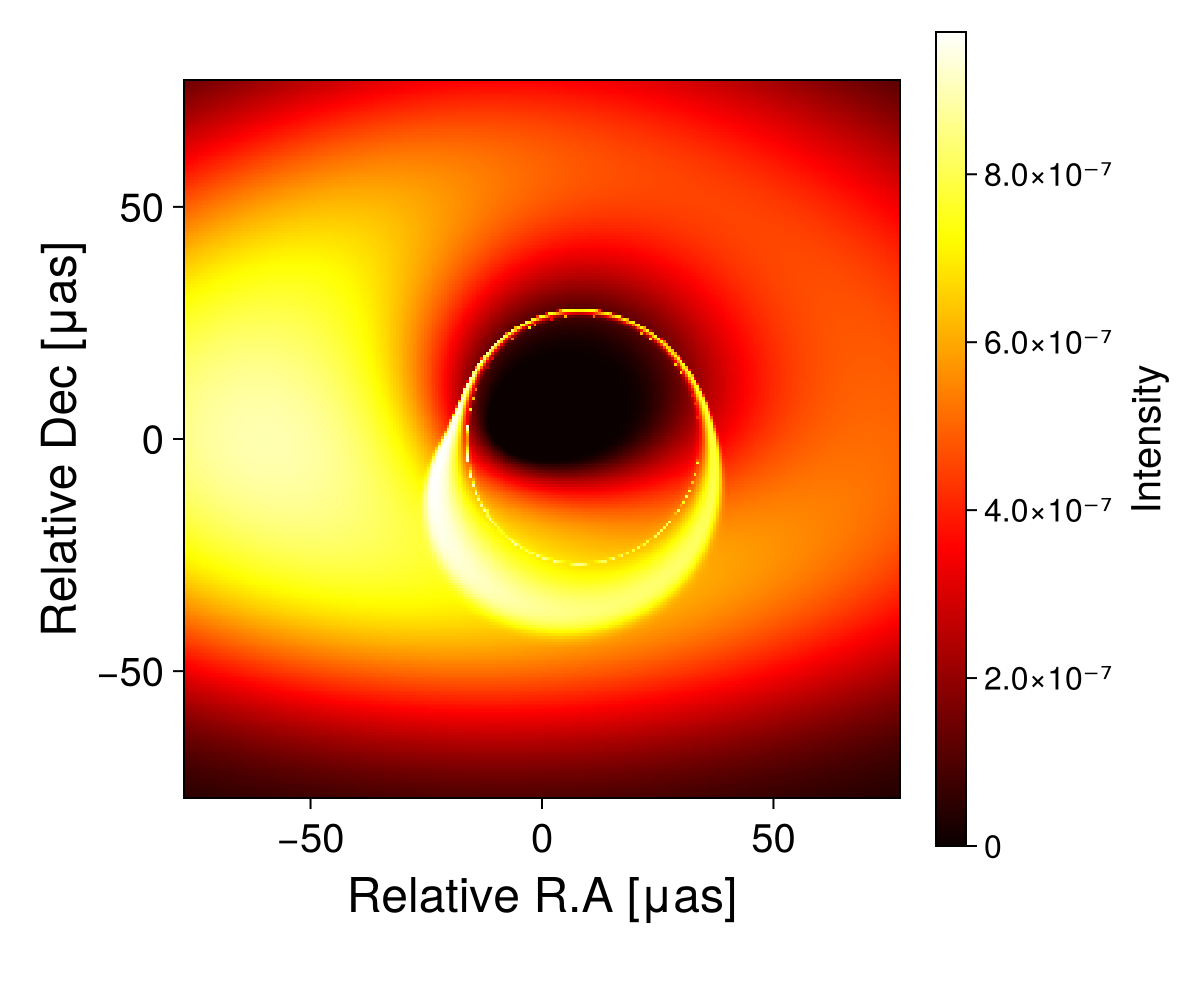

In [7]:
using CairoMakie



d_kpc = 7.78
d_cm = d_kpc * 3.086e21           
fov_rg = 30
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm   
theta_μas = theta_rad * MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)


Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)
hm = heatmap!(ax, x, y, Image; colormap=:hot, colorrange=crange)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig

# Thin Disk Model

In [1]:
const MODEL = "thin_disk"
const MBH = 10.0
const SLOW_LIGHT = false
include("../src/main.jl")

Using model: thin_disk, change src/set_globals.jl to modify.
Current path is /data/pedro/Jipole_folders/Jipole-slow/example_notebooks


[ Info: Chandra table loaded successfully from /data/pedro/Jipole_folders/Jipole-slow/src/models/../../Tables/ch24_vals.txt


main (generic function with 1 method)

In [2]:
#THIN DISK PARAMETERS
#Setting up the parameters
#Observer distance in Rg
const ro = 10000.0
#Observer inclination in degrees
const th = 75.0

#Observer azimuth in degrees
const phi = 0.0

# Size of the screen in Rg in both directions
const DXsize = 40.0
const DYsize = 40.0

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const res = 256
const pixels_x = 256
const pixels_y = 256

# Distance to the source in parsecs
const SourceD = 0.05 * PC
const Rout = 1000.0
const Rstop = 10000.0

# Frequency observed by the camera in Hz
const freq = 2.417989e17#230e9
const bhspin = 0.99
const Rh = 1 + sqrt(1. - bhspin * bhspin);
const cstartx = MVec4(0.0, log(Rh), 0.0, 0.0)
const cstopx = MVec4(0.0, log(1000.0), 1.0, 2.0 * π);
const Mdotedd = 4 * π * GNEWT * MBH * MSUN * MP/(0.1)/CL/SIGMA_THOMPSON
const Mdot = 0.01 * Mdotedd 
const z1 = 1.0 + (1.0 - bhspin^2)^(1.0 / 3.0) * ((1.0 + bhspin)^(1.0 / 3.0) + (1.0 - bhspin)^(1.0 / 3.0))
const z2 = sqrt(3.0 * bhspin^2 + z1^2)
const r_isco = 3.0 + z2 - copysign(sqrt((3.0 - z1) * (3.0 + z1 + 2.0 * z2)), bhspin)
const T0 = (3.0 / (8.0)/π * GNEWT * MBH * MSUN * Mdot / L_unit^3 / SIG)^(1.0 / 4.0);

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0;

In [3]:
const metric = METRIC_MKS
const params = GlobalParams(bhspin, Rout, cstartx, cstopx, metric);

In [4]:
using ProgressMeter

# Calculate the camera position in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, params.a, params.Rout))

# Unitless frequency 
const freq_unitless = freq * HPL / (ME * CL * CL)

#Array that will hold the Intensity value for each pixel
Image = zeros(Float64, pixels_x, pixels_y)

#Number of threads used in the calculation
const nthreads = Threads.nthreads() + 1

println("Allocating workspaces for $nthreads threads...")
#Number of maximum steps in the geodesic calculation
const maxnstep = 15000

#Allocating the vector that will keep track of the position of each photon
dummy_svec = @SVector zeros(4)
dummy_traj = OfTrajS(0.0, dummy_svec, dummy_svec, dummy_svec, dummy_svec)
thread_trajs = [Vector{OfTrajS}(undef, maxnstep) for _ in 1:nthreads]
for t in 1:nthreads
    for k in 1:maxnstep
        thread_trajs[t][k] = dummy_traj
    end
end


p = Progress(
    pixels_x * pixels_y; 
    desc = "Raytracing Image...", 
    showspeed = true, 
    barlen = 30
)
ProgressMeter.ijulia_behavior(:clear)

println("Tracing Geodesics...")
Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid() 
    
    for j in 0:(pixels_y - 1)
        # Pass the thread-specific traj and lconn
        nstep, _ = get_pixel(
            thread_trajs[tid], i, j, Xcamera, 
            fovx, fovy, freq_unitless, 
            pixels_x, pixels_y, params.a, 
            Rh, params.Rout, Rstop,xoff, yoff
        ) 
        
        integrate_emission!(
            thread_trajs[tid], nstep, Image, 
            i + 1, j + 1, freq, params.a
        )
        ProgressMeter.next!(
                p; 
                showvalues = [
                    (:thread_id, tid), 
                    (:pixel, "($i, $j)"), 
                    (:total_done, "$(i*pixels_y + j)/$(pixels_x * pixels_y)")
            ]
        )
    end
end
Image *= freq^3
finish!(p);

Raytracing Image... 100%|██████████████████████████████| Time: 0:00:08 ( 0.13 ms/it)
    thread_id: 3
        pixel: (159, 255)
   total_done: 40959/65536


In [6]:
const scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)
OutputStokesParameters(Image, freq, scale_factor, res, SourceD) 

Image processing complete. Calculating total flux and averages...
Scale = 2.237608086843551e-01
imax = 109, jmax = 135, Imax = 19007.867654192323, Iavg = 467.74025421242413
Total Flux Fnu = 6.859124738411619e+06 Jy
nuLnu = 4.9610556953165605e36


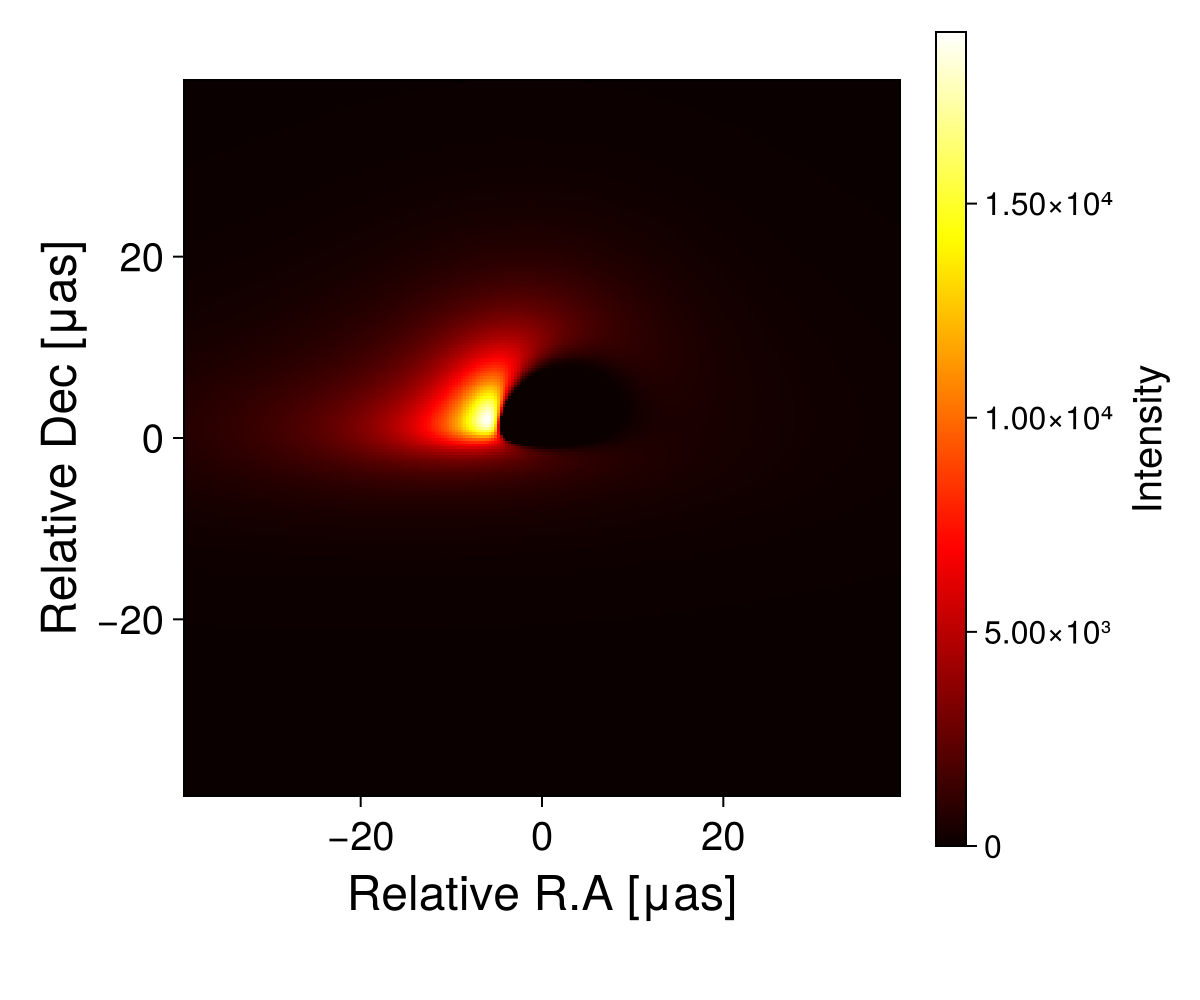

In [7]:
using CairoMakie
using Printf


d_kpc = 0.05 * 1/1000
d_cm = d_kpc * 3.086e21           
fov_rg = 40
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm   
theta_μas = theta_rad * MUAS_PER_RAD       
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)


Ny, Nx = size(Image)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

fig = Figure(size = (600, 500))

ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)

crange = extrema(Image)
hm = heatmap!(ax, x, y, Image; colormap=:hot, colorrange=crange)

Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig